# The Normal Equation

In [3]:
import numpy as np

X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100,1)

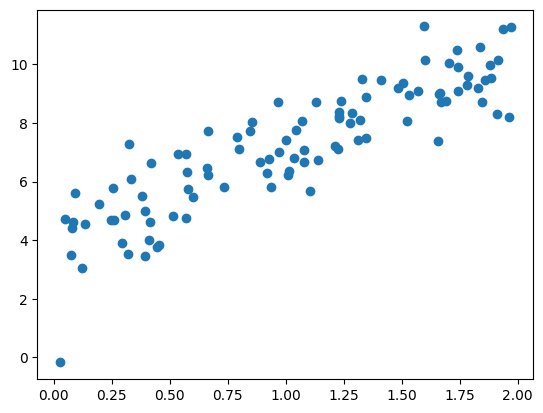

In [5]:
import matplotlib.pyplot as plt

plt.scatter(X, y)
plt.show()

In [6]:
# Applying The Normal Equation formula
X_b = np.c_[np.ones((100,1)), X]
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

In [7]:
theta_best

array([[3.87415054],
       [3.23810471]])

In [10]:
# Making predictions using \theta_best
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2,1)), X_new]
y_predict = X_new_b.dot(theta_best)
y_predict

array([[ 3.87415054],
       [10.35035996]])

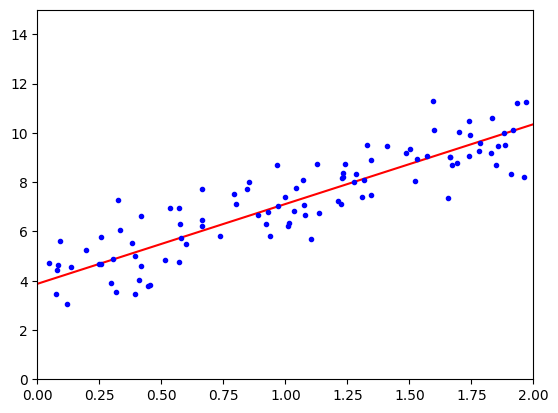

In [14]:
plt.plot(X_new, y_predict, "r-")
plt.plot(X, y, "b.")

plt.axis([0,2,0,15])
plt.show()

In [15]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([3.87415054]), array([[3.23810471]]))

In [16]:
lin_reg.predict(X_new)

array([[ 3.87415054],
       [10.35035996]])

In [17]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[3.87415054],
       [3.23810471]])

We use pseudoinverse X+ instead of inverse here

In [18]:
np.linalg.pinv(X_b).dot(y)

array([[3.87415054],
       [3.23810471]])

# Gradient Descent

## Batch Gradient Descent

In [19]:
eta = 0.1 # learning rate
n_iterations = 1000
m = 100 

theta = np.random.randn(2, 1) # Random initialization

for iteration in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients

In [20]:
theta

array([[3.87415054],
       [3.23810471]])

## Stochastic Gradient Descent

In [25]:
n_epochs = 50
t0, t1 = 5, 50 # learning schedule hyperparameters

def learning_schedule(t):
    return t0/ (t+t1)

theta = np.random.randn(2, 1) # random initialization

for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(epoch * m + i)
        theta = theta - eta * gradients

In [27]:
theta

array([[3.79153263],
       [3.30069401]])

For stochastic gradient descent, the training instances must be independent and identically distributed (IID), to ensure that the parameters get pulled towards the global optimum, on average

In [28]:
# using sklearn's SGDRegressor to perform Linear Regression using SGD
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.1)
sgd_reg.fit(X, y.ravel())

,loss,'squared_error'
,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,None


In [29]:

sgd_reg.intercept_, sgd_reg.coef_

(array([3.86032379]), array([3.24970173]))

## Mini-batch Gradient Descent

Instead of computing the gradients based on the full-training set (as in Batch GD) or based on just one instance (as in Stochastic GD), Mini-batch GD computes the gradients on small random sets of instances called mini-batches


# Polynomial Regression

In [30]:
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

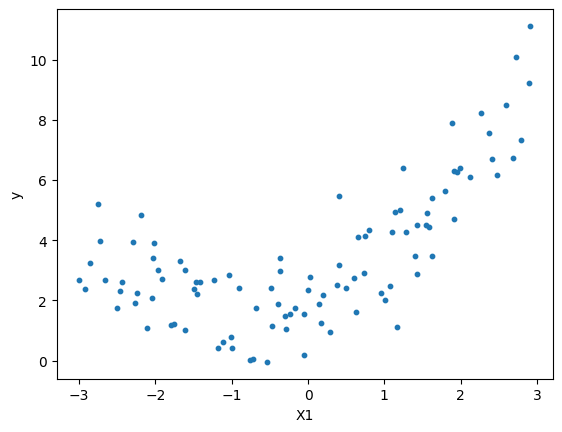

In [34]:
plt.scatter(X, y, s=10)
plt.xlabel("X1")
plt.ylabel("y")
plt.show()

In [35]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X[0]

array([-0.72429977])

In [40]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([2.00769726]), array([[0.94310233, 0.53432152]]))

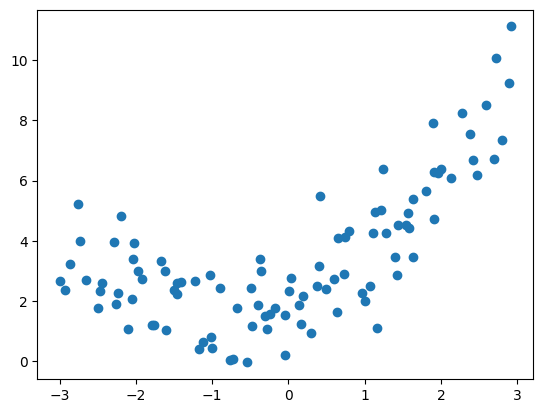

In [45]:
plt.scatter(X, y)
plt.show()

In [83]:
# plot the learning curves of a model
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def plot_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)
    train_errors, val_errors = [], []
    for m in range(1, len(X_train)):
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
        val_errors.append(mean_squared_error(y_val, y_val_predict))
    # we do sqrt to calculate the rmse
    plt.plot(np.sqrt(train_errors), "r-+", linewidth=2, label="train")
    plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="val")
    plt.xlabel("Epochs (m)")
    plt.ylabel("RMSE")
    plt.xlim(0, 80)
    plt.ylim(0, 3)
    plt.legend()

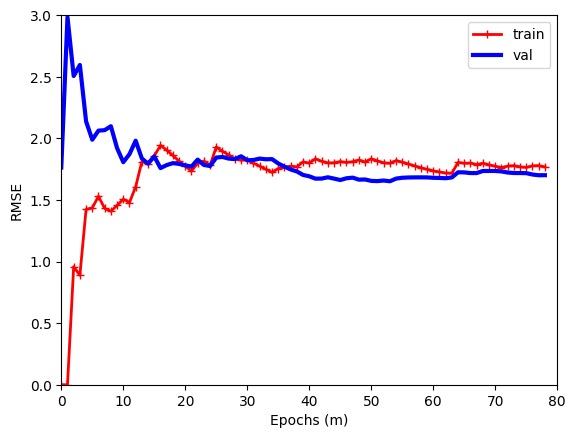

In [75]:
lin_reg = LinearRegression()
plot_learning_curves(lin_reg, X, y)

The LinearRegression model underfits. 
Trying 10th-degree polynomial model on the same data

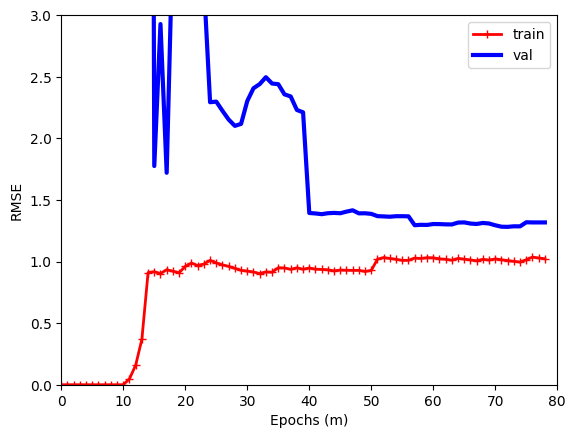

In [76]:
from sklearn.pipeline import Pipeline

polynomial_regression = Pipeline([
    ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
    ("lin_reg", LinearRegression()),
])

plot_learning_curves(polynomial_regression, X, y)

# Ridge Regression

In [77]:
# Ridge Regression with Scikit-Learn using a matrix factorization technique by Andre-Louis Cholesky
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=1, solver="cholesky")
ridge_reg.fit(X, y)

,alpha,1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'cholesky'
,positive,False
,random_state,None


In [78]:
ridge_reg.predict([[1.5]])

array([4.78397481])

In [79]:
# Using stochastic gradient descent
sgd_reg = SGDRegressor(penalty="l2")
sgd_reg.fit(X, y.ravel())
sgd_reg.predict([[1.5]])

array([4.75960679])

# Lasso Regression
aka _Least Absolute Shrinkage_ and _Selection Operator Regression_

In [80]:
from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([4.73256971])

# ElasticNet
a mix of ridge and lasso regression

In [81]:
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X, y)
elastic_net.predict([[1.5]])

array([4.73690132])

# Early Stopping
stopping training as soon as the validation error reaches minimum

In [91]:
# Basic implementation of early stopping

from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

# prepare the data
poly_scaler = Pipeline([
    ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
    ("std_scaler", StandardScaler())
])
X_train, X_val, y_train, y_val = train_test_split(X, y.ravel(), test_size=0.2, random_state=42)
X_train_poly_scaled = poly_scaler.fit_transform(X_train)
X_val_poly_scaled = poly_scaler.transform(X_val)

sgd_reg = SGDRegressor(max_iter=1, tol=None, warm_start=True,
                       penalty=None, learning_rate="constant", eta0=0.0005)
minimum_val_error = float("inf")
best_epoch = None
best_model = None
for epoch in range(1000):
    sgd_reg.fit(X_train_poly_scaled, y_train)
    y_val_predict = sgd_reg.predict(X_val_poly_scaled)
    val_error = mean_squared_error(y_val, y_val_predict)
    if val_error < minimum_val_error:
        minimum_val_error = val_error
        best_epoch = epoch
        best_model = clone(sgd_reg)

# Logistic Regression

## Decision Boundries

In [92]:
from sklearn import datasets
iris = datasets.load_iris()
list(iris.keys())

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [100]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [103]:
X = iris["data"][:, 3:] # petal width
y = (iris["target"] == 2).astype(int)

In [106]:
# train a logistic regression Model
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


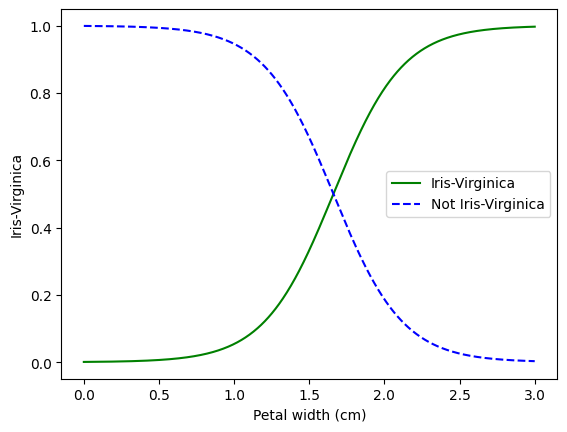

In [111]:
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new)
plt.plot(X_new, y_proba[:, 1], "g-", label="Iris-Virginica")
plt.plot(X_new, y_proba[:, 0], "b--", label="Not Iris-Virginica")
plt.xlabel("Petal width (cm)")
plt.ylabel("Iris-Virginica")
plt.legend()

In [112]:
log_reg.predict([[1.7], [1.5]])

array([1, 0])

Applying Softmax regression to classify the iris flowers into all three classes.
Scikit-learn's LogisticRegression uses one-versus-all by default

In [114]:
X = iris["data"][:, (2, 3)] # petal length, pental width
y = iris["target"]

softmax_reg = LogisticRegression(solver="lbfgs", C=10)
softmax_reg.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [115]:
softmax_reg.predict([[5, 2]])

array([2])

In [116]:
softmax_reg.predict_proba([[5, 2]])

array([[6.21626374e-07, 5.73689802e-02, 9.42630398e-01]])